<font color='DarkBlue' size=+2><b>Комментарий ревьюера</b></font><br>
<font color='DarkBlue'>Привет, Денис! <br>Меня зовут Олег Мазуренко, и я буду проверять этот проект. Спасибо за проделанную работу! <br>Ко мне можно обращаться на «ты». Как мне обращаться, напиши.</font><br> <font color='Blue'><b>Привет! Давай на ты</b></font>

<font color='DarkBlue'>Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</font><br>
<font color='DarkBlue'>Синий текст &mdash; просто текст комментария.</font><br>
<font color='DarkGreen'>👌 Зеленый текст &mdash; все отлично.</font><br>
<font color='DarkMagenta'>👉 Фиолетовый текст &mdash; сделано все правильно, однако есть рекомендации, на что стоит обратить внимание. Реализованные рекомендации позволят нам наработать опыт решения задачи разными способами или посмотреть на задачу под иным углом.</font><br>
<font color='Red'>🛠 Красный текст &mdash; есть недочеты, они иногда бывают. </font><br><font color='DarkBlue'>Любая ошибка это возможность посмотреть на задачу с другой стороны и освоить новые знания, по этому не надо расстраиваться, если они есть.</font><br>
<font color='DarkBlue'>Обращаю внимание, что комментарии ревьюера после проверки удалять нельзя они помогают отследить логику исправления или изменения проекта. Это дополнительный навык при обучении. Свой исправляемый код лучше тоже не удалять, а ремить #, это позволит акцентировать изменения в ходе подготовки окончательного варианта проекта.<br>
Ответы на мои комментарии лучше тоже помечать. 
Например: </font><font color='Blue'><b>Комментарий студента</b></font><br>
<font color='DarkBlue'><b>Теперь посмотрим, что получилось!</b></font>

# Изучение рынка заведений общественного питания Москвы

- Автор:Еренков Денис
- Дата: 20.05.2026

### Цели и задачи проекта

- Цель: Провести комплексное исследование рынка общественного питания Москвы для определения оптимальных параметров открытия нового заведения, которое будет максимально соответствовать рыночным трендам и предпочтениям потребителей.
- Задачи:
1. Изучить структуру рынка по категориям заведений.
2. Проанализировать географическое распределение заведений по районам Москвы.
3. Исследовать соотношение сетевых и несетевых заведений.
4. Определить типичную вместимость (количество мест) для разных категорий.
5. Проанализировать рейтинги заведений и факторы, влияющие на них.
6. Изучить ценовую политику и средние чеки в разных районах.
7. Выявить популярные сети и их особенности.
8. Проанализировать режим работы заведений (круглосуточные и другие).

### Описание данных

#### Основные данные о заведениях (rest_info.csv):
name — название заведения

address — адрес заведения

district — административный район (например, Центральный административный округ)

category — категория заведения (кафе, пиццерия, кофейня и др.)

hours — информация о днях и часах работы

rating — рейтинг заведения по оценкам пользователей Яндекс Карт (шкала от 0 до 5.0)

chain — признак сетевого заведения:

0 — не сетевое

1 — сетевое

seats — количество посадочных мест

#### Данные о ценах (rest_price.csv):
price — категория цен (средние, ниже среднего, выше среднего и т.д.)

avg_bill — строковое описание средней стоимости заказа (диапазоны цен)

middle_avg_bill — числовая оценка среднего чека (только для записей, начинающихся с "Средний счёт")

middle_coffee_cup — числовая оценка стоимости чашки капучино (только для записей, начинающихся с "Цена одной чашки капучино")

### Содержимое проекта

1. Загрузка и предобработка данных
2. Анализ структуры рынка
3. Анализ сетевых заведений
4. Анализ вместимости заведений
5. Анализ рейтингов и качества
6. Ценовой анализ
7. Анализ режима работы
8. Итоговые выводы и рекомендации

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, сделано описание проекта. 👍</font>

## 1. Загрузка данных и знакомство с ними


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
!pip install phik

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что инсталлируем библиотеку `phik`.</font>

In [2]:
from phik import phik_matrix

In [3]:
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Очень хорошо! Загрузка датасетов непосредственно с сервера и все равно от куда запускается тетрадка. 👍</font>

- Познакомимся с данными и изучим общую информацию о них.

In [4]:
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
rest_info.isnull().sum()

id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64

In [7]:
rest_info['hours'].isnull().sum()/len(rest_info)

0.06376397811087318

In [8]:
rest_info['seats'].isnull().sum()/len(rest_info)

0.4295741137282893

Датасет rest_info содержит информацию о заведениях общественного питания Москвы и включает 8 406 записей с 9 характеристиками для каждого заведения. 
- Названия столбцов соответствуют стандарту snake_case
- Обнаружены пропуски в столбцах hours (536 пропусков) и seats (3611 пропусков)
- Столбец chain содержит бинарные значения (0/1) — можно оптимизировать размерность
- Столбец seats хранит целочисленные значения в формате float64 — требует преобразования
- Все основные характеристики заведений заполнены полностью (id, name, category, address, district, rating)

In [9]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [10]:
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [11]:
rest_price.isnull().sum()

id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64

In [12]:
rest_price['price'].isnull().sum()/len(rest_price)

0.1830951207491375

In [13]:
rest_price['avg_bill'].isnull().sum()/len(rest_price)

0.05963528831936915

Датасет rest_price содержит информацию о ценах в заведениях общественного питания Москвы и включает 4 058 записей с 5 характеристиками.
- Значительное количество пропусков почти во всех слобцах, для middle_avg_bill и  middle_coffee_cup это нормально, поскольку столбцы являются категориями столбца avg_bill. 
- Столбец avg_bill содержит разнородные данные о ценах в текстовом формате 
- Столбец middle_avg_bill и  middle_coffee_cup имеют тип float64, можно оптимизировать
- Столбец middle_coffee_cup заполнен только для 535 записей 

In [14]:
rest_price['price'].unique()

array(['выше среднего', 'средние', nan, 'высокие', 'низкие'], dtype=object)

---

### Промежуточный вывод



Объём данных: 8406 заведений, 4058 записей о ценах. Количество мест как дробное число вместо целого. Есть неоптимальные форматы данных в chain, seats, middle_avg_bill, middle_coffee_cup 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, исследовали общую информацию о датасетах и сделали промежуточные выводы.</font>

### Подготовка единого датафрейма

- Объединим данные двух датасетов в один

In [15]:
df = rest_info.merge(rest_price, how = 'left', on = 'id')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно объединили датасеты в одну таблицу, проверили результат.</font>

Дабы не потерять почти половину данных о заведениях, объединение производилось с помощью left join

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Лучше перед обработкой данных делать контроль размера датасета до и после обработки. Примерно вот так:</font>

In [17]:
# Комментарий ревьюера
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = df.copy() 
len(temp)

8406

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Копия исходного датасета позволяет:
- Сделать расчет удаленных строк после предобработки.
- Делать проверку преобразований данных в процессе обработки, сравнивая их с исходным датасетом и контролируя возможные ошибки.</font>

## 2. Предобработка данных

Подготовим данные к исследовательскому анализу: в пункте 1.1 мы ознакомились с типами данных, теперь перейдем к их преобразованию. 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вот, что написано в задании: <br><b>Изучите корректность типов данных и при необходимости проведите их преобразование. Помните, что наличие пропусков в данных может влиять на их тип.</b> <br>Не изучены типы данных, следует использовать метод `.dtypes`. Следует рассмотреть возможность понижения разрядности числовых данных, сделать выводы анализа.</font>
<font color='Blue'>Исправил</font>

In [18]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Можно еще понизить разрядность числовых данных с 64 до 32, примерно вот так:<br>
`df['chain'] = pd.to_numeric(df['chain'], downcast='integer')`<br>
`for column in ['rating','middle_avg_bill','middle_coffee_cup','seats']:`<br>
&nbsp;&nbsp;&nbsp;&nbsp;`df[column] = pd.to_numeric(df[column], downcast='float')`</font>

In [19]:
df.isna().sum() / df.shape[0]
# доля пропуксов в каждом стобце

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

In [20]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Можно вот так вывести информацию о пропусках:</font>

In [21]:
# Комментарий ревьюера 2
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Для анализа необходимо вывести количество пропусков и в абсолютных значениях.</font>

<font color='Blue'>Исправил</font>

Гипотезы появления пропусков:

Из 13 колонок 7 заполнены полностью (id, name, category, address, district, rating, chain)

6 колонок имеют пропуски

- seats (43%) - данные о вместимости часто не публикуются онлайн
- Ценовые данные (55-94%) - многие заведения не указывают цены в открытых источниках
- hours (6%) - редкие случаи отсутствия информации о режиме работы
- middle_coffee_cup (94%) - заполнены только для кофеен и баров

In [22]:
df['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

In [23]:
# hours - небольшой процент пропусков, заполняем
df['hours'] = df['hours'].fillna('режим работы не указан')

In [24]:
#опитимизируем тип данных, шде хранится 0 и 1
df['chain'] = df['chain'].astype('int8')

df['seats'] = pd.to_numeric(df['seats'], errors='coerce')
df['seats'] = df['seats'].astype('Int64')

df['rating'] = df['rating'].astype('float32')

In [25]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                  Int64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [26]:
df['price'] = df['price'].fillna('не указано')
df['avg_bill'] = df['avg_bill'].fillna('не указано')

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Заполнять пропуски или нет.<br><br>
<b>Когда пропуски можно оставить не заполненными:</b><br>
<b><i>Неважность пропущенных данных.</b></i> Если пропущенные значения не играют решающей роли в анализе и не влияют на выводы, пропуски можно оставить пустыми. Особенно актуально, если они касаются второстепенных признаков.<br>
<b><i>Высокий процент пропусков.</b></i> Если пропуски составляют значительный процент (например, более 30–40%) и заполнить их корректно затруднительно, лучше оставить пропуски как есть, чтобы избежать искажения данных.<br>
<b><i>Экспериментальные данные.</b></i> В случае, когда исследование направлено на выявление шаблонов или тенденций, пропуски могут использоваться как индикатор недостатка информации, что само по себе является важным сигналом.<br>
<b><i>Фильтрация данных.</b></i> Если последующий анализ предусматривает фильтрацию или агрегацию данных, пропуски могут быть просто исключены из анализа без последствий.<br>
<b><i>Ранжирование или классификация.</b></i> При проведении классификации или ранжирования пропуски могут оставаться пустыми, если они не участвуют в формировании ключевых признаков.<br><br>
<b>Когда пропуски желательно заполнять значениями-индикаторами:</b><br>
<b><i>Небольшое количество пропусков.</b></i> Если пропуски редко встречаются (например, менее 5%), их можно заполнить специальным значением, например, "_MISSING_", чтобы отразить их наличие.<br>
<b><i>Специальные потребности модели.</b></i> Некоторые алгоритмы машинного обучения (например, Random Forest, LightGBM) поддерживают пропуски, но предпочитают иметь дополнительные сигналы, такие как значение-индикатор, чтобы точнее учитывать их влияние.<br>
<b><i>Маркетинговые или социальные исследования.</b></i> В маркетинговых и социальных исследованиях пропуски могут нести важную информацию о поведении аудитории (например, отказ указать контактную информацию может сигнализировать о недоверии).<br>
<b><i>Классификация и сегментация.</b></i> В задачах классификации или сегментации наличие пропуска может стать отдельным признаком, помогающим улучшить точность модели.<br>
<b><i>Специфичность признаков.</b></i> Если знак пропусков важен для понимания поведения или характеристик данных (например, "отсутствие информации" свидетельствует о низкой активности пользователя), полезно использовать значение-индикатор.<br>
<i>Выбор подхода зависит от специфики задачи и целей анализа.</i></font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Допустимая замена пропусков заглушками (значением-индикатором). Только при анализе заглушки надо будет отфильтровывать.</font><br>
<font color='DarkMagenta'>👉 Но надо иметь в виду, что правильно построить матрицу корреляции по столбцам с заглушками не удастся, так как заглушки искажают анализ, а при фильтрации заглушки в одном столбце теряются значимые данные в других столбцах. По этому в этой задаче необходимо будет обратно заменить заглушки на пропуски, пропуски не мешают расчету корреляции и анализу.</font>

In [27]:
has_avg_bill_no_middle = df[(df['avg_bill'].notna()) & (df['middle_avg_bill'].isna())]
print(f"Записей с avg_bill но без middle_avg_bill: {len(has_avg_bill_no_middle)}")
# анализируем содержание таких записей
if len(has_avg_bill_no_middle) > 0:
    # примеры avg_bill без middle_avg_bill:
    print(has_avg_bill_no_middle['avg_bill'].unique()[:10])

Записей с avg_bill но без middle_avg_bill: 5257
['не указано' 'Цена чашки капучино:155–185 ₽' 'Цена бокала пива:250–350 ₽'
 'Цена бокала пива:120–350 ₽' 'Цена чашки капучино:150–190 ₽'
 'Цена чашки капучино:120–170 ₽' 'Цена чашки капучино:100–200 ₽'
 'Цена бокала пива:90–230 ₽' 'Цена чашки капучино:150–210 ₽'
 'Цена чашки капучино:80–160 ₽']


Обоснование: Заполнение этих пропусков привело бы к искажению данных, так как пропуски означают отсутствие соответствующей информации, а не ошибку в данных. Заполнены только записи, где avg_bill начинается с "Средний счёт". Аналогичная ситуация и с middle_coffee_cup, где данные только о кофе

In [28]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,не указано,не указано,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,не указано,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN


- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [29]:
# проверка на явные дубликаты
df.duplicated().sum()

0

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, что проверены явные дубликаты, иногда они сильно искажают анализ.</font>

In [30]:
df['name'].duplicated().sum()

2792

In [31]:
# проверим неявные дубликаты по id
df.duplicated(subset='id').sum()

0

In [32]:
# преобразуем названия и адреса к одному виду
df['name'] = df['name'].str.lower().str.strip()
df['district'] = df['district'].str.lower().str.strip()

In [33]:
# приведем адреса к одному виду
def normalize_address(address):
    address = address.lower()
    replacements = {
        'ул.': 'улица',
        'пр.': 'проспект',
        'пер.': 'переулок',
        'наб.': 'набережная',
        'ш.': 'шоссе',
        'б-р': 'бульвар',
        'пр-т': 'проспект',
        'м.': 'метро',
        'д.': 'дом',
        'корп.': 'корпус',
        'стр.': 'строение',
        'к.': 'корпус'
    }
    for short, full in replacements.items():
        address = address.replace(short, full)
    address = ' '.join(address.split())
    return address
df['address'] = df['address'].apply(normalize_address)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, нормализовали данные категорийных столбцов.</font>

In [34]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,не указано,не указано,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корпус 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,не указано,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN


In [35]:
# cохраняем информацию о количестве дубликатов перед удалением
duplicates_before = df.duplicated(subset=['name', 'category', 'address'], keep=False).sum()
print(f"Дубликатов перед удалением: {duplicates_before}")
print(f"Записей перед удалением: {len(df)}")
# eдаляем дубликаты, оставляя первое вхождение
df = df.drop_duplicates(subset=['name', 'category', 'address'], keep='first')
print(f"Осталось записей: {len(df)}")


Дубликатов перед удалением: 4
Записей перед удалением: 8406
Осталось записей: 8404


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, обработали дубликаты.</font>
<br><font color='DarkMagenta'>👉 Следовало их посмотреть перед удалением.</font>

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [36]:
def check_24_7(hours_str):
    hours_lower = hours_str.lower()
    hours_lower = hours_str.strip()
    round_the_clock_indicators = [
        'ежедневно, круглосуточно',
        'ежедневно,круглосуточно'
    ]
    
    for indicator in round_the_clock_indicators:
        if indicator in hours_lower:
            return True
        return False
    
df['is_24_7'] = df['hours'].apply(check_24_7)

In [37]:
# Комментарий ревьюера
df['is_24_7'].value_counts()

False    7674
True      730
Name: is_24_7, dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Корректно создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения и других.</font>

In [38]:
df.head(15)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,не указано,не указано,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корпус 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,не указано,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN,False
5,8a343546b24e4a499ad96eb7d0797a8a,sergio pizza,пиццерия,"москва, ижорская улица, вл8б",северный административный округ,"ежедневно, 10:00–23:00",4.6,0,<NA>,средние,не указано,NaN,NaN,False
6,96ebceb1a09e4e3191133b9fe0379a64,огни города,"бар,паб","москва, клязьминская улица, 9, строение 3",северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45,средние,Средний счёт:199 ₽,199.0,NaN,False
7,0243288b78024af090b8e947842c969c,mr. уголёк,быстрое питание,"москва, клязьминская улица, 9, строение 3",северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45,средние,Средний счёт:200–300 ₽,250.0,NaN,False
8,36aeb0ffa69c48fdb0021549520deb10,donna maria,ресторан,"москва, дмитровское шоссе, 107, корпус 4",северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79,средние,Средний счёт:от 500 ₽,500.0,NaN,False
9,487167877eb04288bc90d4fa80646fc2,готика,кафе,"москва, ангарская улица, 39",северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65,средние,Средний счёт:1000–1200 ₽,1100.0,NaN,False


In [39]:
initial_count = 8406  # исходное количество после объединения
final_count = len(df)
duplicates_removed = initial_count - final_count

print(f"1. ДУБЛИКАТЫ:")
print(f"   Исходно: {initial_count} записей")
print(f"   После удаления дубликатов: {final_count} записей")
print(f"   Удалено: {duplicates_removed} записей")

1. ДУБЛИКАТЫ:
   Исходно: 8406 записей
   После удаления дубликатов: 8404 записей
   Удалено: 2 записей


In [40]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8404 
 Удалено строк в датасете после обработки 2 
 Процент потерь 0.02


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

 Обработка пропусков:

   
Полностью заполнены: id, name, category, address, district, rating, chain

Частично заполнены: hours, seats, price, avg_bill

Общая информация

Исходный размер: 8 406 × 13

После обработки: 8 404 × 14

Потери: 2 строки (0.02%)

Данные: заведения общепита Москвы (название, адрес, категория, часы работы, рейтинг, признак сети, места, цены)

Типы данных

chain: int64 → int8

seats: float64 → Int64

rating: float64 → float32

category, district, price: object → category

Итог: все типы корректны

Дубликаты

Явные: 0

Неявные (name+category+address): 2 → удалены

Новые признаки: is_24_7 — круглосуточное заведение (8.7% от всех)

Итог

Данные готовы к анализу

Ограничение: ценовые данные (middle_avg_bill, middle_coffee_cup) имеют намеренные пропуски

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не корректный вывод. И такая замена была бы ошибкой.</font> <font color='Blue'>Исправил</font>
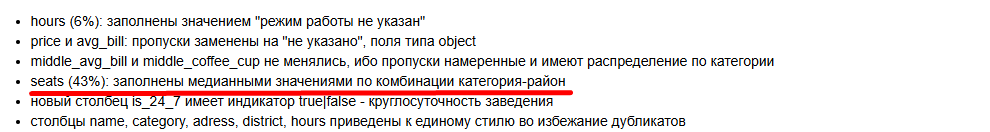<br>
<font color='DarkMagenta'>👉 Промежуточный вывод по разделу первичного анализа и предобработки данных должен быть лаконичным, структурированным и давать чёткое понимание текущего состояния данных перед переходом к следующему этапу (например, исследовательскому анализу или моделированию).

<b>Структура промежуточного вывода:</b>
1. <b><i>Общая информация о данных</b></i>
- Размер исходного (объединенного) датасета (строки × колонки)
- Размер после всех преобразований (если изменился)
- Краткое описание набора данных (о чём данные)

2. <b><i>Типы данных</b></i>
- Какие преобразования типов были выполнены. Пример: "Приведены типы: колонки с датами преобразованы в datetime, числовые колонки — в float/int, категориальные — в category"
- Указать, все ли колонки имеют корректные типы

3. <b><i>Пропуски</b></i>
- Количество пропусков до обработки (по колонкам или общее)
- Метод обработки (удаление / заполнение средним / медианой / модой и т.д.)
- Количество пропусков после обработки (обычно 0, если не осталось)

4. <b><i>Дубликаты</b></i>
- Количество явных дубликатов (полных)
- Количество неявных дубликатов (по ключевым полям)
- Метод обработки (удаление / объединение)
- Что осталось после обработки

5. <b><i>Информация о создании дополнительных столбцов/признаков если требуется в задании брифа.</b></i>

    
6. <b><i>Итоговое состояние данных</b></i>
- Количество строк после всех преобразований
- Краткий вывод о готовности данных к дальнейшему анализу
</font>

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [41]:
category_stats = df['category'].value_counts()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Правильно было бы дополнительно проверить и распределение заведений в относительных значениях, для этого стоило воспользоваться методом `.value_counts()` с параметром `normalize=True`.</font> <font color='Blue'>Добавил</font>
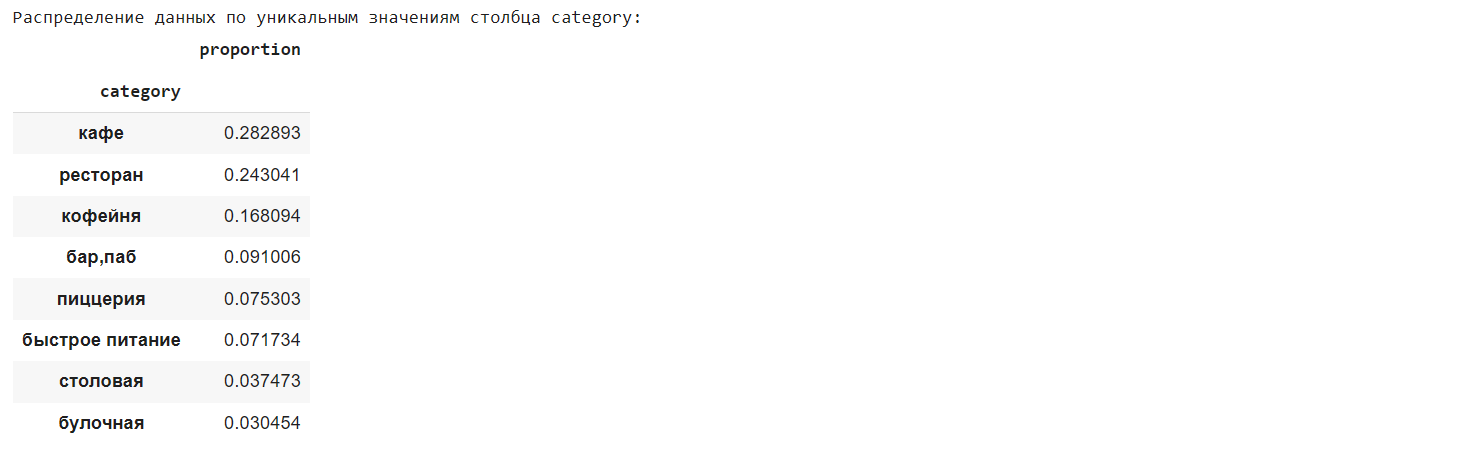

In [42]:
df['category'].value_counts(normalize=True)

кафе               0.282842
ресторан           0.242980
кофейня            0.168134
бар,паб            0.091028
пиццерия           0.075321
быстрое питание    0.071752
столовая           0.037482
булочная           0.030462
Name: category, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Стандартный подход к анализу данных, смотрим абсолютные и относительные значения. Если какие-то значения выводим прямо на диаграммах, то в табличном виде можно не показывать.<br>
Абсолютные значения отвечают на вопрос: «Сколько?»<br>
Относительные значения отвечают на вопрос: «Какую часть?»<br>
Вместе они дают полную картину:<br>
- Где сосредоточены основные игроки.<br>
- Какие категории перспективны для развития.<br>
- Как меняется структура рынка с течением времени.<br>
    
Это особенно важно для бизнес-планирования, анализа конкуренции и прогнозирования трендов.<br>
</font>

топ 3 занимает ~68% рынка

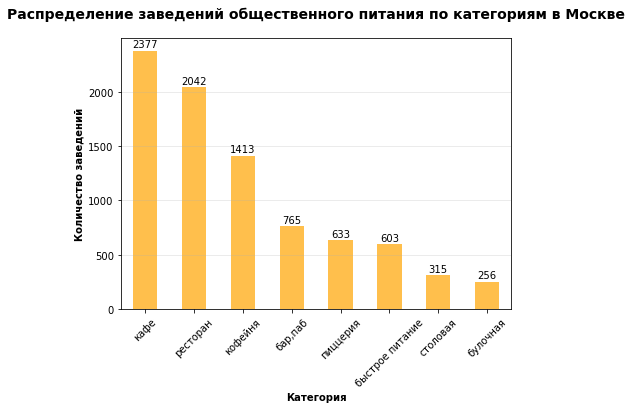

In [43]:

ax = df['category'].value_counts().plot(kind='bar', 
               rot=0, 
               legend=False,
               figsize = (7,5),
               color='orange',
               alpha=0.7
)
for i, v in enumerate(df['category'].value_counts()):
    ax.text(i, v + 10, str(v), 
            ha='center', va='bottom', 
            fontsize=10)
plt.title('Распределение заведений общественного питания по категориям в Москве', fontsize=14, fontweight='bold', pad=20) 
plt.xlabel('Категория', fontweight='bold')
plt.ylabel('Количество заведений', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.show()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошая визуализация и правильно, что оси подписаны и есть название графика.</font>

1. Рынок сверхконцентрирован

Топ 3 типа: кафе, рестораны, кофейни занимают ~68% рынка

Вывод: Если открывать классический формат — сразу попадаешь в самую конкурентную среду. Нужно четкое УТП.

2. Огромное "разнообразие" оставшегося рынка

Остальные 5 категорий делят между собой лишь 32% рынка

Вывод: Нишевые форматы (пиццерии, бургерные, столовые) имеют меньше конкурентов, но и меньший общий спрос

3. Рекомендация по стратегии:

| Сценарий | Что делать |
|----------|------------|
| Хотите быстрый старт | Идите в **кафе или ресторан** — большой рынок, но высокая конкуренция |
| Хотите выделиться | Выбирайте **среднюю категорию** (бар/паб, столовая, бургерная) — спрос есть, игроков меньше |
| Эксперимент | **Нишевая категория** (восточная, пекарня, фалафельная) — низкая конкуренция, но нужен точный подбор локации |

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Вывод: Две трети рынка заняты «легкими» форматами, сегментированными на «посидеть» и «перекусить»

1. <b>Группировка и интерпретация</b><br>
- Рынок общепита Москвы не монолитен: <b>кафе и рестораны суммарно занимают более половины всех заведений (52.5%)</b>. Однако, если объединить их с кофейнями и барами, получится, что <b>~78% точек</b> относятся к форматам, ориентированным на <b>длительное времяпрепровождение</b> (посидеть, поработать, встретиться).<br>

2. <b>Сравнение и бизнес-смысл</b>
-   <b>Кафе (28%)</b> и <b>Рестораны (24%)</b> — абсолютные лидеры. Это «золотая середина»: первый привлекает демократичностью, второй — статусом.
-   <b>Кофейни (17%)</b> — третий по величине сегмент, что подтверждает тренд на «кофе с собой» и коворкинг.
-   <b>Бары (9%)</b> замыкают топ-4, показывая стабильный, но более узкий спрос на вечерний досуг.
-   <b>Быстрое питание (7%)</b> и <b>Столовые (3.7%)</b> находятся в минорной позиции, что говорит о высокой конкуренции со стороны уличной еды и форматов «готового обеда» в магазинах.<br>

3. <b>Рекомендации</b>
-   <b>Для массового трафика:</b> Открывать <b>кафе</b> (универсальный формат) или <b>кофейню</b> (быстрая окупаемость).
-   <b>Для высокой маржи:</b> Внедрять гибридные форматы (кофейня-пекарня, ресторан-бар), чтобы захватить аудиторию нескольких сегментов.
-   <b>Аутсайдерам (столовые, бургерные):</b> Выход в спальные районы с высоким пешеходным трафиком, где спрос на «дешевый обед» остается неудовлетворённым из-за удаленности от офисов.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 От куда эти цифры? В анализе их нет.</font>
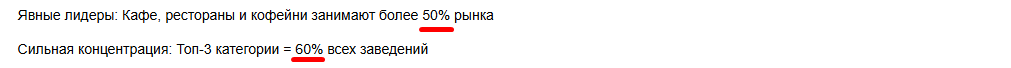<br>
<font color='DarkMagenta'>👉 <b>ЧЕК-ЛИСТ ПРАВИЛЬНОГО ВЫВОДА:</b><br>
✅ <b>ДОЛЖЕН СОДЕРЖАТЬ:</b>
- Интерпретацию данных (а не их перечисление).
- Относительные показатели (доли, проценты, соотношения).
- Сравнения (больше/меньше, выше/ниже, лидер/аутсайдер).
- Группировку (сегменты, категории, кластеры).
- Бизнес-смысл (что это значит для принятия решений).
- Рекомендации (что делать на основе выводов).

❌ <b>НЕ ДОЛЖЕН СОДЕРЖАТЬ:</b>
- Простое перечисление чисел из таблиц.
- Описание того, что и так видно на графиках.
- Технические детали анализа (как считали).
- Бездоказательные утверждения.
- Повторение введения/постановки задачи.
    
💥 <b>ЗОЛОТОЕ ПРАВИЛО:<br></b>
Вывод = Ответ на вопрос "SO WHAT?" ("И ЧТО С ТОГО?")<br>
Если после прочтения вывода возникает вопрос "Ну и что?" — это плохой вывод.<br>
Хороший вывод сам отвечает на этот вопрос.</font><font color='Blue'>Исправил</font>


---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [44]:
df['district'].value_counts()

центральный административный округ         2242
северный административный округ             898
южный административный округ                892
северо-восточный административный округ     891
западный административный округ             851
восточный административный округ            798
юго-восточный административный округ        714
юго-западный административный округ         709
северо-западный административный округ      409
Name: district, dtype: int64

In [45]:
df['district'].value_counts(normalize=True)

центральный административный округ         0.266778
северный административный округ            0.106854
южный административный округ               0.106140
северо-восточный административный округ    0.106021
западный административный округ            0.101261
восточный административный округ           0.094955
юго-восточный административный округ       0.084960
юго-западный административный округ        0.084365
северо-западный административный округ     0.048667
Name: district, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Не проверили распределение по административным районам в относительных значениях, для этого стоило воспользоваться методом `.value_counts()` с параметром `normalize=True`.</font> <font color='Blue'>Исправил</font>

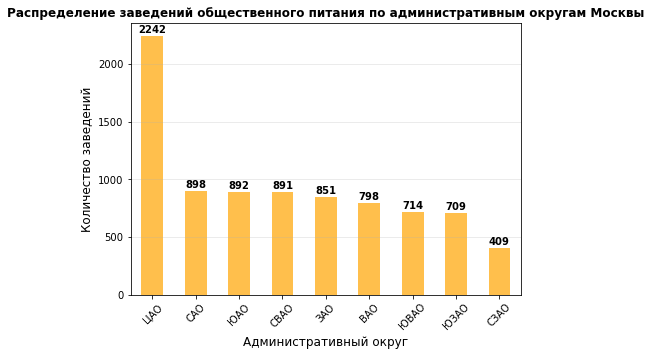

In [46]:
district_abbr = {
    'центральный административный округ': 'ЦАО',
    'северный административный округ': 'САО', 
    'южный административный округ': 'ЮАО',
    'северо-восточный административный округ': 'СВАО',
    'западный административный округ': 'ЗАО',
    'восточный административный округ': 'ВАО',
    'юго-восточный административный округ': 'ЮВАО',
    'юго-западный административный округ': 'ЮЗАО',
    'северо-западный административный округ': 'СЗАО'
}

district_counts_abbr = df['district'].value_counts().rename(index=district_abbr)
plt.figure(figsize=(7, 5))
ax = district_counts_abbr.plot(kind = 'bar',color='orange', alpha=0.7,rot = 0.5)
plt.title('Распределение заведений общественного питания по административным округам Москвы', 
          fontsize=12, fontweight='bold')
plt.xlabel('Административный округ', fontsize=12)
plt.ylabel('Количество заведений', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)


for bar in ax.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало использовать столбчатую диаграмму с горизонтальным расположением, примерно вот так:</font>
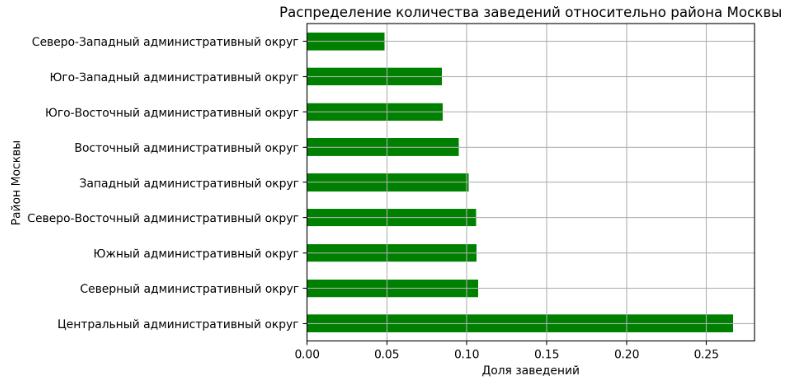

Можно заметить, что в ЦАО сконцентрировано абсолютное большинство заведений - 2242, во всех остальных районах Москвы, кроме СЗАО примерно одинаковое кол-во заведений ~800, в СЗАО всего лишь 409 точек общественного питания. Сердце столицы предоставляет высокие цены на аренду и огромную конкуренцию в самом туристическом округе.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что анализ заканчивается промежуточным выводом с описанием полученных результатов.</font>

In [47]:
cao_data = df[df['district'] == 'центральный административный округ']
cao_category_stats = cao_data['category'].value_counts()
cao_category_stats

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

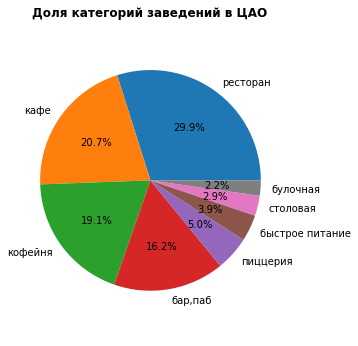

In [48]:
plt.figure(figsize=(5, 5))
plt.pie(cao_category_stats.values, labels=cao_category_stats.index, autopct='%1.1f%%')
plt.title('Доля категорий заведений в ЦАО', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что проанализировали категории заведений в ЦАО.</font>

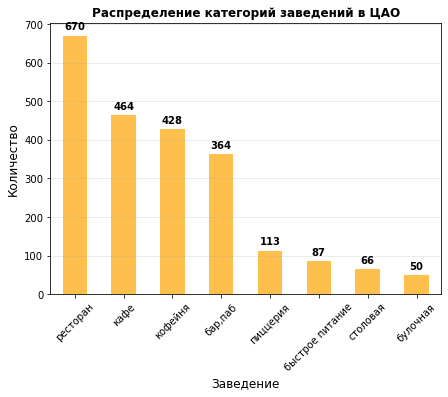

In [49]:
plt.figure(figsize=(7, 5))
ax = cao_data.groupby('category')['category'].count().sort_values(ascending=False).plot(
    kind='bar', color='orange', alpha=0.7, rot=0)

plt.title('Распределение категорий заведений в ЦАО', 
          fontsize=12, fontweight='bold')
plt.xlabel('Заведение', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)


for bar in ax.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()


В ЦАО наибольший процент заведений (29.9%) - рестораны, кафе и кофеен на 10% меньше, наименее популярны столовые и булочные. (Центр Москвы располагает к более культурным, пафосным и высококачественным заведениям)

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Преобладание ресторанов в центре и кафе на окраинах — это не случайность, а отражение разной экономики, аудитории и функций этих территорий. Центр — место для «выхода в свет», спальные районы — для повседневной жизни. Это важно учитывать при любом анализе, сравнивающем центр с остальными округами.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font>
<br><font color='DarkMagenta'>👉 Следовало отметить различие в топ категориях в ЦАО и по всем округам (задание 1).</font>

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

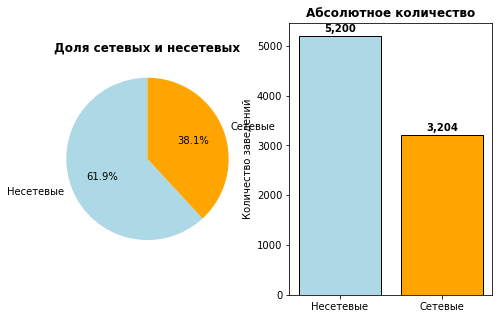

In [50]:
chain_counts = df['chain'].value_counts()
non_chain = chain_counts.get(0, 0)
chain = chain_counts.get(1, 0)

plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)
plt.pie(chain_counts, labels=['Несетевые', 'Сетевые'], 
        autopct='%1.1f%%', colors=['lightblue', 'orange'], 
        startangle=90)
plt.title('Доля сетевых и несетевых', fontsize=12, fontweight='bold')
plt.ylabel('')

plt.subplot(1, 2, 2)
bars = plt.bar(['Несетевые', 'Сетевые'], [non_chain, chain], 
               color=['lightblue', 'orange'], edgecolor='black')
plt.title('Абсолютное количество', fontsize=12, fontweight='bold')
plt.ylabel('Количество заведений')

for bar, value in zip(bars, [non_chain, chain]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{value:,}', ha='center', va='bottom', fontweight='bold')


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало добавить распределение сетевых и не сетевых заведений и в абсолютных значениях.</font><font color='Blue'>Скорректировал</font>

Несетевые заведения преобладают над сетевыми, далле выясним какие именно

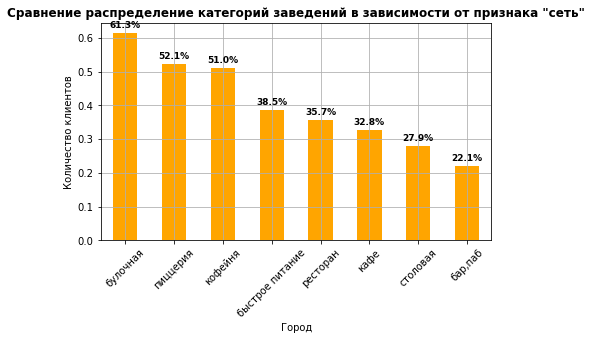

In [51]:
grouped = (df[df['chain'] == 1].groupby('category').size() / df.groupby('category').size()).sort_values(ascending=False)
ax = grouped.plot(kind='bar',
               ylabel='Количество клиентов',
               xlabel='Город',
               rot=0,
                  color = 'orange',
               figsize=(7, 4))

for i, v in enumerate(grouped):
    ax.text(i, v + 0.01, f'{v:.1%}', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

plt.grid()
plt.title(f'Сравнение распределение категорий заведений в зависимости от признака "сеть"', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.show()



<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, сделана визуализация долей категорий сетевых заведений.</font>

Лидером среди сетевых заведений являются булочные, их доля составляет 61,1%, в отличие от баров и пабов (всего 22,1%  сетевых). Примерно поровну сетевых и несетевых пиццерий и кофеен (52,1% и 51% соответственно)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Что данный анализ означает для бизнеса?</font> <font color='Blue'>Скорректировал</font>

1. Булочные — НЕ заходить, если вы не сеть

61% рынка уже поделен между сетевыми игроками

Независимой булочной будет крайне сложно конкурировать по цене и узнаваемости

Решение: Отказаться от этого формата или сразу планировать сетевую экспансию

2. Бары и пабы — ЗАХОДИТЬ, если вы независимый игрок

Сетевых всего 22% — рынок не монополизирован

Гостям не нужен бренд, им нужна атмосфера

Решение: Отличная ниша для частного заведения с душой

3. Пиццерии и кофейни — ОБА ВАРИАНТА возможны

Рынок поделен примерно 50/50

Сетевые выигрывают за счет стандартов и скорости

Независимые — за счет уникальности (авторская пицца, обжарка кофе)

Решение: Выбирайте по вашим сильным сторонам: стандартизация → сеть, уникальность → независимость

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Результат анализа:
- Вывод с бизнес-интерпретацией:<br>
Сегменты быстрого питания (кофейни, пиццерии, булочные) демонстрируют высокий уровень консолидации — более 50% заведений являются сетевыми. Это говорит о том, что рынок уже поделён крупными игроками, а конкуренция строится на узнаваемости бренда и стандартизации сервиса.<br>
- Добавляем рекомендации:<br>
Для входа в эти сегменты новым игрокам потребуется либо значительный бюджет на маркетинг, либо уникальная концепция, отличающаяся от существующих сетей. Инвесторам стоит обратить внимание на франшизы в этих категориях — они уже доказали свою жизнеспособность.</font>

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вот, что написано в задании: <br><b>Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны?</b></font><br>
<font color='DarkMagenta'>👉 Этот анализ необходимо сделать по всем заведениям, до анализа по категориям. Для этого следует использовать сводную статистику, гистограмму и диаграмму размаха по всем значениям посадочных мест без разбивки по категориям. Сделать выводы по аномалиям.</font>

 1. ресторан                  медиана:   86 мест, среднее:  122 мест
 2. бар,паб                   медиана:   82 мест, среднее:  124 мест
 3. кофейня                   медиана:   80 мест, среднее:  111 мест
 4. столовая                  медиана:   76 мест, среднее:  100 мест
 5. быстрое питание           медиана:   65 мест, среднее:   99 мест
 6. кафе                      медиана:   60 мест, среднее:   98 мест
 7. пиццерия                  медиана:   55 мест, среднее:   94 мест
 8. булочная                  медиана:   50 мест, среднее:   89 мест


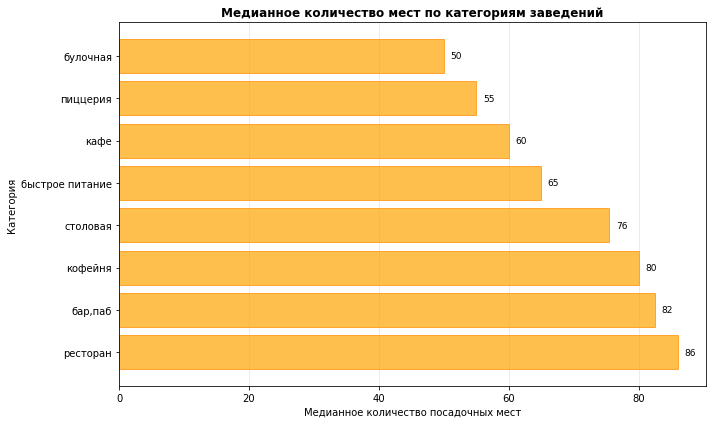

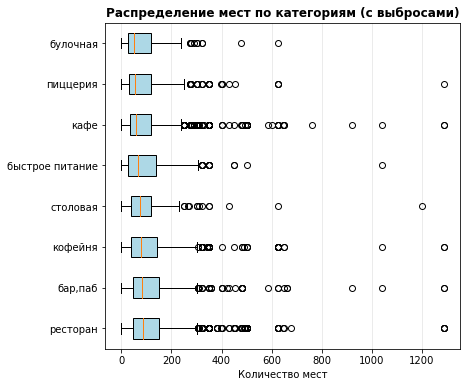

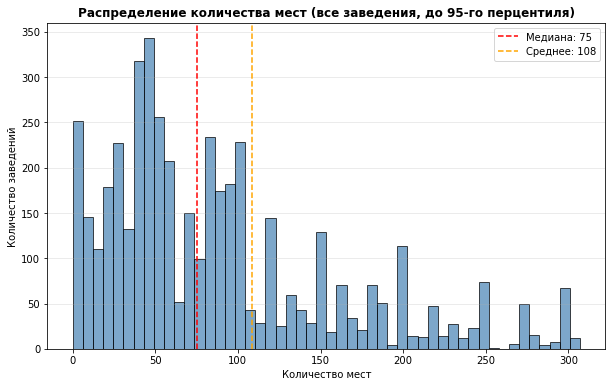

In [52]:
# Выявление выбросов методом IQR
Q1 = df['seats'].quantile(0.25)
Q3 = df['seats'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['seats'] < lower_bound) | (df['seats'] > upper_bound)]

category_seats_stats = df.groupby('category')['seats'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(1)
category_seats_stats = category_seats_stats.sort_values('median', ascending=False)
for i, (category, stats) in enumerate(category_seats_stats.head(15).iterrows(), 1):
    print(f"{i:2d}. {category:<25} медиана: {stats['median']:>4.0f} мест, среднее: {stats['mean']:>4.0f} мест")


# Визуализация 1: Медианное количество мест по категориям
plt.figure(figsize=(10, 6))
bars = plt.barh(category_seats_stats.head(15).index, 
                category_seats_stats.head(15)['median'], 
                color='orange', alpha=0.7, edgecolor='darkorange')
plt.xlabel('Медианное количество посадочных мест')
plt.ylabel('Категория')
plt.title('Медианное количество мест по категориям заведений', 
          fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Визуализация 2: Boxplot для выявления выбросов
plt.figure(figsize=(14, 6))

# Boxplot по топ-категориям
top_categories = category_seats_stats.head(10).index
data_for_box = [df[df['category'] == cat]['seats'].dropna() for cat in top_categories]

plt.subplot(1, 2, 1)
bp = plt.boxplot(data_for_box, labels=top_categories, vert=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
plt.xlabel('Количество мест')
plt.title('Распределение мест по категориям (с выбросами)', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
'''
# Гистограмма распределения
plt.subplot(1, 2, 2)
plt.hist(df['seats'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df['seats'].median(), color='red', linestyle='--', 
            label=f'Медиана: {df["seats"].median():.0f}')
plt.axvline(df['seats'].mean(), color='orange', linestyle='--', 
            label=f'Среднее: {df["seats"].mean():.0f}')
plt.xlabel('Количество мест')
plt.ylabel('Количество заведений')
plt.title('Распределение количества мест (все заведения)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
'''
# Убираем строки с NaN в seats для корректного расчёта статистики
seats_clean = df['seats'].dropna()

#(только для непустых значений)
Q1 = seats_clean.quantile(0.25)
Q3 = seats_clean.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['seats'] < lower_bound) | (df['seats'] > upper_bound)]
category_seats_stats = df[df['seats'].notna()].groupby('category')['seats'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(1)

category_seats_stats = category_seats_stats.sort_values('median', ascending=False)

plt.figure(figsize=(10, 6))
q95 = seats_clean.quantile(0.95)
seats_filtered = seats_clean[seats_clean <= q95]

plt.hist(seats_filtered, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(seats_clean.median(), color='red', linestyle='--', 
            label=f'Медиана: {seats_clean.median():.0f}')
plt.axvline(seats_clean.mean(), color='orange', linestyle='--', 
            label=f'Среднее: {seats_clean.mean():.0f}')
plt.xlabel('Количество мест')
plt.ylabel('Количество заведений')
plt.title('Распределение количества мест (все заведения, до 95-го перцентиля)', 
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='Red'>🛠 Ошибка кода. К сожалению, я не могу продолжить ревью. 😢</font>
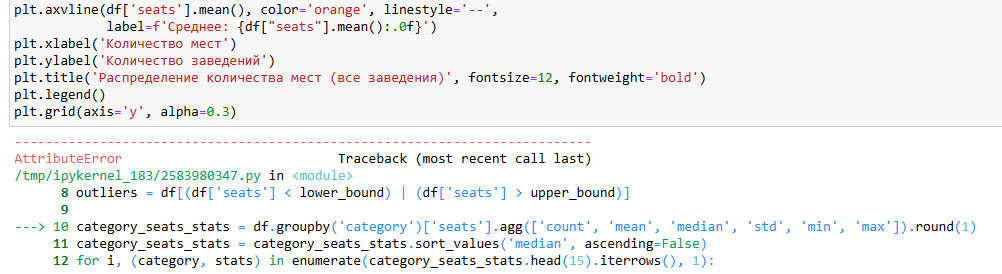

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что для анализа типичного колличества посадочных мест по категориям заведений использованы медианные значения, так  как распределение данных имеет выбросы и ассимметрично. </font>

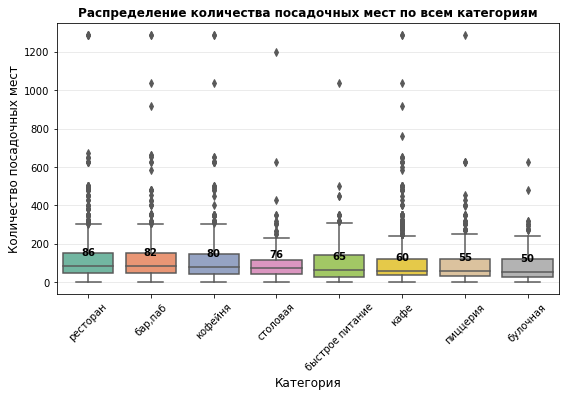

In [53]:
# боксплоты по всем категориям
category_order = df.groupby('category')['seats'].median().sort_values(ascending=False).index
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='category', y='seats', palette='Set2', order=category_order)
plt.title('Распределение количества посадочных мест по всем категориям', 
          fontsize=12, fontweight='bold')
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Количество посадочных мест', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

medians = df.groupby('category')['seats'].median().sort_values(ascending=False)
for i, (category, median) in enumerate(medians.items()):
    plt.text(i, median + 45, f'{median:.0f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold')
plt.show()


In [54]:
# анализ аномальных значений
very_large_seats = df[df['seats'] > 300]
if len(very_large_seats) > 0:
    print("Заведения с очень большим количеством мест (>300):")
    for _, row in very_large_seats.iterrows():
        print(f"  - {row['name']} ({row['category']}): {row['seats']} мест, {row['district']}")

very_small_seats = df[df['seats'] < 5]
if len(very_small_seats) > 0:
    print(f"\nЗаведения с очень малым количеством мест (<5): {len(very_small_seats)}")
    for _, row in very_small_seats.head(5).iterrows():
        print(f"  - {row['name']} ({row['category']}): {row['seats']} мест")

Заведения с очень большим количеством мест (>300):
  - арарат (кафе): 350 мест, северо-восточный административный округ
  - one price coffee (кофейня): 350 мест, северо-восточный административный округ
  - вуди пицца (пиццерия): 350 мест, северный административный округ
  - ленкорань (кафе): 350 мест, северо-восточный административный округ
  - грузинский бульвар (быстрое питание): 350 мест, северо-восточный административный округ
  - vasilchukí chaihona №1 (ресторан): 398 мест, северный административный округ
  - бота (пиццерия): 398 мест, северный административный округ
  - styling bull cafe (столовая): 310 мест, северо-западный административный округ
  - восточная кухня (кафе): 320 мест, северо-западный административный округ
  - эскалоп (пиццерия): 350 мест, северный административный округ
  - сундук (ресторан): 350 мест, северный административный округ
  - сады семирамиды (ресторан): 350 мест, северный административный округ
  - чайхона №1 (ресторан): 310 мест, северо-восточный ад

- Возможные причины аномалий в крупных заведений: банкетные залы ("чайхона №1" - 625 мест), фуд-корты в торговых центрах, столовые в бизнес-центрах, значения > 1000 могут являться аномалиями, вызванными как ошибками данных
- Возможные причины аномалий в крупных заведений: для заведений быстрого питания отсутствие мест либо минимальное количество вполне адеквартно, так как часто это формат шаурмы, где еда только навынос, а ресторан с 4 посадочными местами действительно существует (одна маленькая комната)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Задание следует заканчивать обобщением результатов анализа типичного количества посадочных мест по категориям.</font>   <font color='Blue'>Скорректировал</font>

1. Не ориентируйтесь на среднее арифметическое

Среднее по городу (~60-70 мест) нереалистично для большинства форматов

Используйте медиану по вашей категории

2. Выбирайте вместимость под формат:

| Если открываете... | Оптимальное количество мест |
|--------------------|------------------------------|
| Бар или паб | 80-100 мест |
| Кофейню | 70-90 мест |
| Столовую | 70-80 мест |
| Кафе | 50-70 мест |
| Пиццерию | 50-60 мест |
| Булочную | 40-50 мест |
| Фастфуд (доставка/киоск) | 0-10 мест |
3. Учитывайте локацию:

В Центральном округе аномалий (500+ мест) больше — это фуд-корты и банкетные залы

В спальных районах типичный размер меньше (40-60 мест)

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Правильно было бы посмотреть сводную статистику рейтингов всех заведений общественного питания  методом `describe()`.</font>
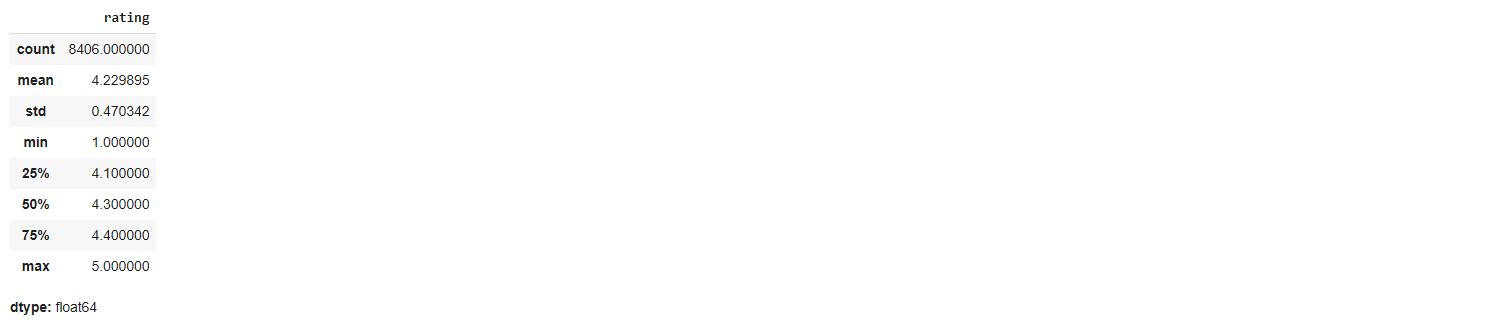

In [55]:
#print(f"Медианный рейтинг")
#df.groupby('category')['rating'].median()

In [56]:
print(f"Средний рейтинг") 
df.groupby('category')['rating'].mean().round(1)

Средний рейтинг


category
бар,паб            4.4
булочная           4.3
быстрое питание    4.1
кафе               4.1
кофейня            4.3
пиццерия           4.3
ресторан           4.3
столовая           4.2
Name: rating, dtype: float32

In [57]:
print(f"Минимальный рейтинг")
df.groupby('category')['rating'].min()

Минимальный рейтинг


category
бар,паб            1.1
булочная           1.3
быстрое питание    1.1
кафе               1.0
кофейня            1.4
пиццерия           1.0
ресторан           1.0
столовая           1.0
Name: rating, dtype: float32

In [58]:
print(f"Максимальный рейтинг")
df.groupby('category')['rating'].max()

Максимальный рейтинг


category
бар,паб            5.0
булочная           5.0
быстрое питание    5.0
кафе               5.0
кофейня            5.0
пиццерия           5.0
ресторан           5.0
столовая           5.0
Name: rating, dtype: float32

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало проанализировать вариации средних рейтингов по категориям заведений, для этого следует использовать метод `.describe()`. Примерно вот так:</font>
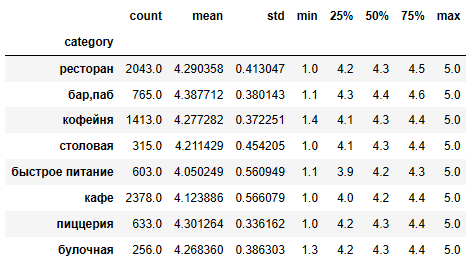

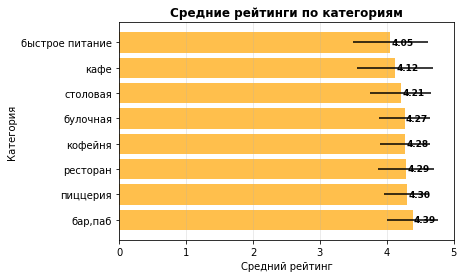

In [59]:
rating_by_category = df.groupby('category')['rating'].agg(['mean', 'count', 'std']).round(3)
rating_by_category = rating_by_category.sort_values('mean', ascending=False)

plt.barh(rating_by_category.index, rating_by_category['mean'], 
         color='orange', alpha=0.7, xerr=rating_by_category['std'], )
plt.title('Средние рейтинги по категориям', fontweight='bold')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x', alpha=0.3)

for i, (category, row) in enumerate(rating_by_category.iterrows()):
    plt.text(row['mean'] + 0.02, i, f'{row["mean"]:.2f}', 
             va='center', fontsize=9, fontweight='bold')


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошая визуализация столбчатой диаграммой рейтинга заведений по категориям.</font>

Рейтинги всех заведений не сильно различны, но стоит отметить, что оценки быстрого питания наиболее низкие по сравнению с остальными. На удивление оценка кафе в среднем ниже, чем столовых и булочных, вероятно людям не нравится обслуживание и качество еды, а со столовых и булочных требований меньше. У заведений быстрого питания и кафе наиболее широкий разброс значений рейтинга. А барф и пабы в среднем оцениваются достаточно высоко.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Обращаю внимание, что диапазон изменения рейтинга от 1 до 5 и разница в 0.5 балла означает разницу в более чем 10%.<br> 
Это может говорить о:
- Различии в качестве обслуживания,
- Уровне удовлетворенности клиентов,
- Конкурентных преимуществах.

А значимость отличия средних значений рейтинга по разным категориям можно проверить другими методами.
</font>

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [60]:
df_corr = df.copy()
# Заменяем заглушки обратно на NaN (пропуски)
df_corr['price'] = df_corr['price'].replace('не указано', np.nan)
df_corr['avg_bill'] = df_corr['avg_bill'].replace('не указано', np.nan)

In [61]:
df_corr_encoded = df_corr.copy()

# Кодируем категории
le_category = LabelEncoder()
le_district = LabelEncoder()

df_corr_encoded['category_encoded'] = le_category.fit_transform(df_corr_encoded['category'].astype(str))
df_corr_encoded['district_encoded'] = le_district.fit_transform(df_corr_encoded['district'].astype(str))

# Для price: кодируем только не-NaN значения, остальное оставляем как NaN
df_corr_encoded['price_encoded'] = df_corr_encoded['price'].copy()
price_mapping = {val: idx for idx, val in enumerate(df_corr_encoded['price'].dropna().unique())}
df_corr_encoded['price_encoded'] = df_corr_encoded['price_encoded'].map(price_mapping)

# Вычисляем корреляционную матрицу через phik (пропуска не мешают)
correlation_matrix = df_corr_encoded[['rating', 'category_encoded', 'district_encoded', 
                                       'chain', 'seats', 'price_encoded', 'is_24_7']].phik_matrix()
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'category_encoded', 'district_encoded', 'chain', 'seats', 'price_encoded']


,rating
price_encoded,0.262056
category_encoded,0.198829
district_encoded,0.189431
is_24_7,0.160994
chain,0.118621
seats,0.000000


<font color='DarkBlue'><b>Комментарий ревьюера</b></font>
<br><font color='Red'>🛠 В разделе предобработки на пропуски в данных были поставлены заглушки и расчет корреляции проводится с ними, соответственно, является не валидным. Но просто отфильтровать заглушки нельзя, так будут одновременно удалены значимые данные по другим столбцам датасета и опять получим невалидный анализ.</font>
<br><font color='DarkMagenta'>👉 В данном случае, чтобы не переделывать раздел предобработки, исправить ошибку можно только, создав копию датасета и в ней заменить заглушку на пропуски. Пропуски не мешают расчету корреляции.</font> <font color='Blue'>Скорректировал</font>

Корреляция рейтинга с остальными значениями достаточно слабая в общем случае, но наиболее явно она выражена для столбца price (0.262).

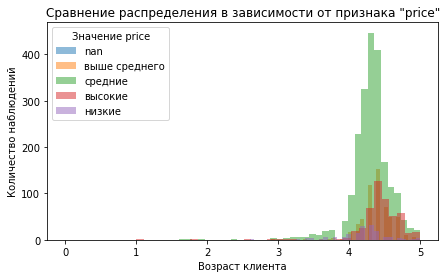

In [62]:
plt.figure(figsize=(7, 4))

for i in df_corr['price'].unique():
    df.loc[df_corr['price'] == i, 'rating'].plot(
        kind='hist',
        bins=37,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределения в зависимости от признака "price"')
plt.xlabel('Возраст клиента')
plt.ylabel('Количество наблюдений')
plt.legend(title='Значение price')
plt.show()

Основная масса значений сконцентрирована в диапазоне 4.0-4.6, причем четкой корреляции на графике не наблюдается, много заведений без категории цен получают оценку в этом диапазоне, что говорит лишь о том, что люди примерно одинаково оценивают все заведения, вне зависимости дорогое оно или нет

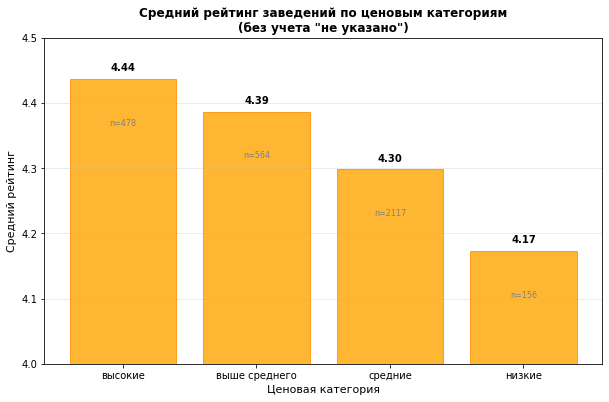

In [63]:
plt.figure(figsize=(10, 6))
df_price_valid = df[df['price'] != 'не указано'].copy()
price_rating_stats = df_price_valid.groupby('price')['rating'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
bars = plt.bar(price_rating_stats.index, price_rating_stats['mean'], 
               color='orange', edgecolor='darkorange', alpha=0.8)
plt.title('Средний рейтинг заведений по ценовым категориям\n(без учета "не указано")', 
          fontsize=12, fontweight='bold')
plt.xlabel('Ценовая категория', fontsize=11)
plt.ylabel('Средний рейтинг', fontsize=11)
plt.ylim(4.0, 4.5)
plt.grid(axis='y', alpha=0.3)

for i, (price, stats) in enumerate(price_rating_stats.iterrows()):
    plt.text(i, stats['mean'] + 0.01, f'{stats["mean"]:.2f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(i, stats['mean'] - 0.06, f'n={int(stats["count"])}', 
             ha='center', va='top', fontsize=8, color='gray');

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 И тут анализ проводится с заглушкой (значением-индикатором), которая не несет ни какой информации для анализа.<br> Для чего предназначена заглушка? Для сохранения значимых данных в других колонках, отличной той, в которой  заменяем пропуски заглушкой. Но когда анализируем данные колонки с заглушками, то последнюю отфильтровываем, так как эти данные не валидны. Если этого не делаем, то получается, что не совсем правильно понимаем назначение заглушки.</font>  <font color='Blue'>Скорректировал</font>
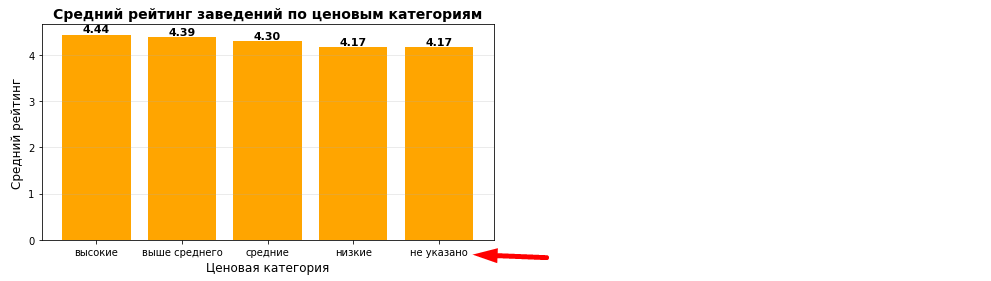

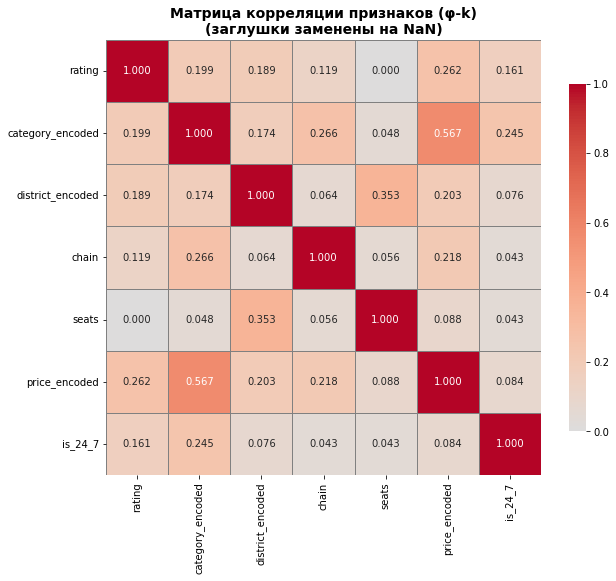

In [64]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, cbar_kws={"shrink": 0.8},
            linewidths=0.5, linecolor='gray')
plt.title('Матрица корреляции признаков (φ-k)\n(заглушки заменены на NaN)', 
          fontsize=14, fontweight='bold');

Ценовая категория (price_encoded = 0.262) — самая сильная, но всё ещё слабая связь

- Клиенты немного лучше оценивают дорогие заведения, чем бюджетные
- Но связь настолько слабая, что цена не является главным драйвером высокой оценки
- Заведение с высокой ценой может получить низкий рейтинг (и наоборот)
- Практический вывод: Ориентироваться только на цену при прогнозировании рейтинга — ошибка.

Количество мест (seats = 0.000)

- Абсолютно нет связи между размером заведения и его рейтингом
- Большие и маленькие заведения оцениваются одинаково
- Практический вывод: Этот признак можно исключить из любого анализа рейтинга — он ничего не даёт.

Общий вывод по слабости всех связей (максимум 0.262)-
- Ни один из проанализированных факторов не объясняет рейтинг заведения
- Настоящие драйверы рейтинга остались за рамками данных: качество еды, скорость обслуживания, вежливость персонала, чистота, атмосфера

In [65]:
# Добавляем порядковый код для корреляции
price_rank_map = {'₽': 1, '₽₽': 2, '₽₽₽': 3, '₽₽₽₽': 4}
df_price_valid['price_rank'] = df_price_valid['price'].map(price_rank_map)
df_price_valid.groupby('price')['rating'].agg([
    ('Количество', 'count'),
    ('Средний рейтинг', 'mean'),
    ('Медиана', 'median'),
    ('Станд. отклонение', 'std'),
    ('Минимум', 'min'),
    ('Максимум', 'max')
]).round(3)

,Количество,Средний рейтинг,Медиана,Станд. отклонение,Минимум,Максимум
price,,,,,,
высокие,478,4.437,4.4,0.314,1.0,5.0
выше среднего,564,4.386,4.4,0.224,2.9,5.0
низкие,156,4.173,4.2,0.373,2.6,5.0
средние,2117,4.298,4.3,0.296,1.6,5.0


Проблема дорогих заведений
- У категории «высокие» наибольший разброс оценок (std = 0.314, min = 1.0). Это значит, что не все дорогие заведения оправдывают ожидания — риск получить низкую оценку выше.

Самая стабильная категория
- «Выше среднего» имеет наименьшее стандартное отклонение (0.224) — клиенты этой ценовой ниши наиболее предсказуемо оценивают заведения.

КЛЮЧЕВОЙ РЕЗУЛЬТАТ

Рейтинг заведения практически не зависит от его характеристик. Максимальная выявленная связь (ценовая категория) объясняет лишь 6.9% вариации рейтинга (0.262² = 0.069). Остальные 93% зависят от других факторов.

СЕГМЕНТАЦИЯ ПО СИЛЕ СВЯЗИ

| Группа | Признаки | Сила связи | Что это значит |
|--------|----------|-----------|----------------|
| **Слабые** | Цена, категория, район | 0.19–0.26 | Влияют, но незначительно |
| **Очень слабые** | Круглосуточный, сетевой | 0.12–0.16 | Почти не влияют |
| **Отсутствует** | Количество мест | 0.00 | Полностью бесполезный признак |

1. Цена не гарантирует качество

- Категория «высокие» лидирует по среднему рейтингу (4.44)

- НО у неё самый высокий разброс оценок (std = 0.314) и минимальная оценка 1.0

- Вывод: Дорогое заведение — это лотерея: можно получить 5 звезд, а можно 1

2. Золотая середина — самая надёжная

- Категория «выше среднего» имеет минимальный разброс оценок (std = 0.224)

- Вывод: Если хотите предсказуемо хорошее впечатление — выбирайте заведения чуть выше среднего чека

3. Бюджетный сегмент — предсказуемо средний

- Категория «низкие» аутсайдер по среднему рейтингу (4.17)

- Вывод: Дешевые заведения редко получают высокие оценки, но и не проваливаются в 1 звезду

4. Размер не имеет значения

- Количество мест коррелирует с рейтингом на 0.000

- Вывод: Маленькое уютное кафе и огромный ресторан оцениваются одинаково. Бесполезный признак для анализа

 Ни один из проанализированных факторов (цена, категория, район, сеть, количество мест, круглосуточный режим) не позволяет прогнозировать рейтинг заведения. Если бизнес хочет повысить оценку — менять надо не цену и не режим работы, а то, что получает клиент внутри: еду, сервис и атмосферу.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не правильный расчет корреляции.</font><br>
<font color='DarkMagenta'>👉 Необходимо переделать весь этот раздел: сделать расчет в табличном виде и визуализацию корреляции рейтинга с указанными в задании признаками, написать выводы. <br>Затем сделать табличный анализ и визуализацию признака с самой сильной связью с рейтингом, сделать выводы.</font>   <font color='Blue'>Поправил</font>

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [66]:
chain_restaurants = df[df['chain'] == 1]
chain_analysis = chain_restaurants.groupby(['name', 'category']).agg({
    'name': 'count',
    'rating': 'mean',
    'category': 'first'
}).round(2)

chain_analysis = chain_analysis.rename(columns={
    'name': 'count',
    'rating': 'avg_rating',
    'category': 'main_cat'
})

top_15_chains = chain_analysis.sort_values('count', ascending=False).head(15)
top_15_chains


,,count,avg_rating,main_cat
name,category,,,
шоколадница,кофейня,119,4.18,кофейня
домино'с пицца,пиццерия,76,4.17,пиццерия
додо пицца,пиццерия,74,4.29,пиццерия
one price coffee,кофейня,71,4.06,кофейня
яндекс лавка,ресторан,69,3.87,ресторан
cofix,кофейня,65,4.08,кофейня
prime,ресторан,49,4.11,ресторан
кофепорт,кофейня,42,4.15,кофейня
кулинарная лавка братьев караваевых,кафе,39,4.39,кафе


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Хочу обратить внимание, что код выше не совсем корректен, так как группировка проводится только по имени заведения, а должна по имени и категории. В итоге, в таблицу попадают заведения, которые имеют несколько категорий, см.код ниже. На скрине таблица топ-15 сгруппированная одновременно по имени и категории.</font>   <font color='Blue'>Скорректировал</font>
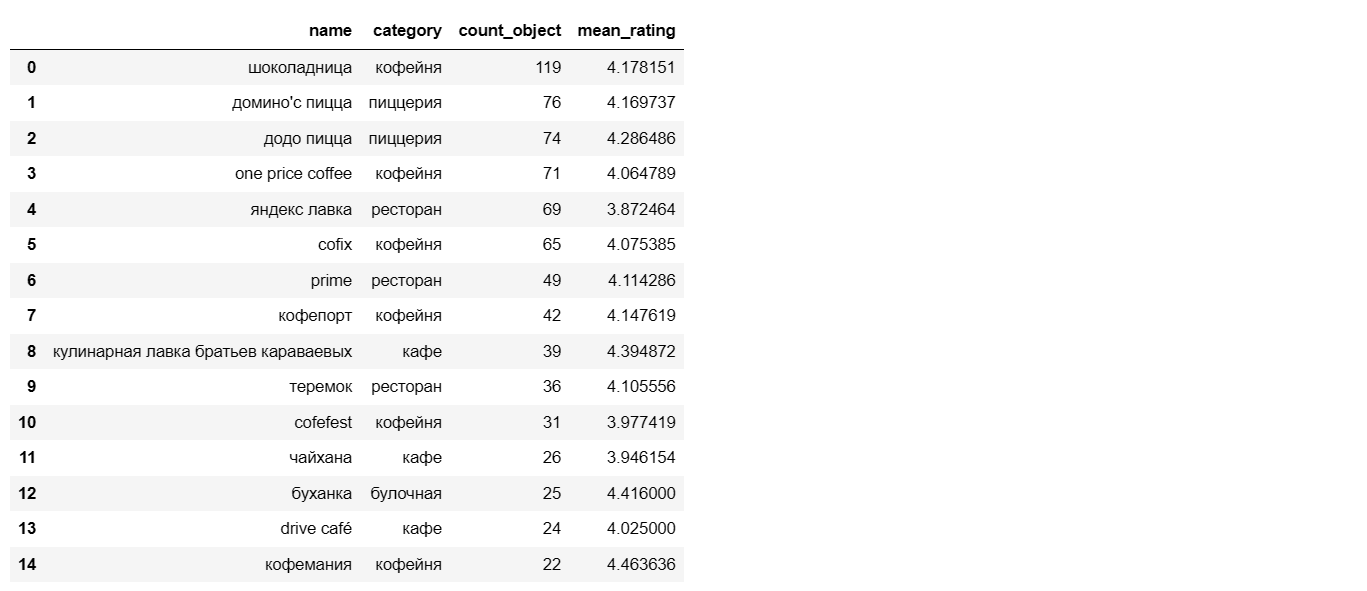 

In [67]:
# Комментарий ревьюера
tmp = df.copy()          # создаем копию текущего датасета
name_tmp = 'му-му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


Распределение по категориям:

Кофейни - 5 сетей (наиболее представленная категория)

Рестораны - 3 сети

Кафе - 3 сети

Пиццерии - 2 сети

Быстрое питание, булочная - по 1 сети

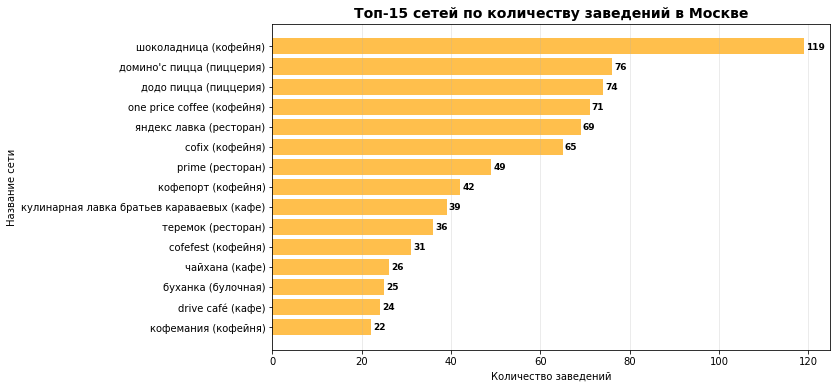

In [68]:
# Способ 1: Сбросить индекс перед построением графика
top_15_chains_reset = top_15_chains.reset_index()
top_15_sorted = top_15_chains_reset.sort_values('count', ascending=True)

plt.figure(figsize=(10, 6))
bars1 = plt.barh(top_15_sorted['name'] + ' (' + top_15_sorted['category'] + ')', 
                  top_15_sorted['count'], 
                  color='orange', alpha=0.7)
plt.title('Топ-15 сетей по количеству заведений в Москве', fontsize=14, fontweight='bold')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.grid(axis='x', alpha=0.3)

for bar in bars1:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно визуализирован топ-15 сетевых заведений.</font>

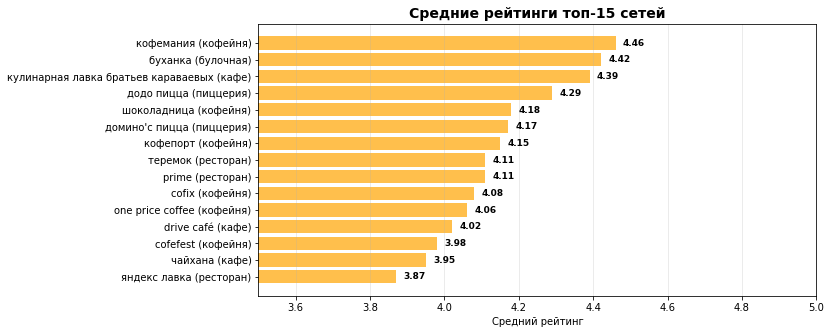

In [69]:
rating_sorted = top_15_chains.sort_values('avg_rating', ascending=True)
labels = [f'{name} ({cat})' for name, cat in rating_sorted.index]

plt.figure(figsize=(10, 5))
bars2 = plt.barh(labels, rating_sorted['avg_rating'], color='orange', alpha=0.7)
plt.xlabel('Средний рейтинг')
plt.title('Средние рейтинги топ-15 сетей', fontsize=14, fontweight='bold')
plt.xlim(3.5, 5.0)
plt.grid(axis='x', alpha=0.3)

for bar in bars2:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно визуализированы средние рейтинги топ-15 сетевых заведений.</font>

Лидеры рынка:
- Шоколадница - абсолютный лидер (120 заведений), кофейня
- Домино'с пицца и Додо пицца - доминируют в сегменте пиццерий
- One price coffee и Cofix - крупные кофейные сети

Качество обслуживания:
- Самые высокие рейтинги: Буханка (4.40), Кулинарная лавка (4.39)
- Самые низкие рейтинги: Яндекс Лавка (3.87), Чайхана (3.92)
- Средний рейтинг топ-сетей: ~4.15


- Масштаб убивает качество (обратная связь)

- В некоторых сегментах рынок поделен между 2-3 игроками (вход новичку закрыт)

- Стратегия демпинга даёт предсказуемо низкий рейтинг

- Маленькие сети с высоким рейтингом — потенциальные цели для M&A

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Какой в этом анализе бизнес-смысл?</font>

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало проанализировать статистические показатели данных по среднему чеку заведений методом `.describe()`.</font><br>
<font color='Red'>🛠 Следует визуализировать анализ среднего чека заведений гистограммой и диаграммой размаха, для оценки размаха распределения, его симметричности и наличия выбросов. Пример на скрине. По итогам анализа сделать выводы.</font>  
 <font color='Blue'>Скорректировал</font>
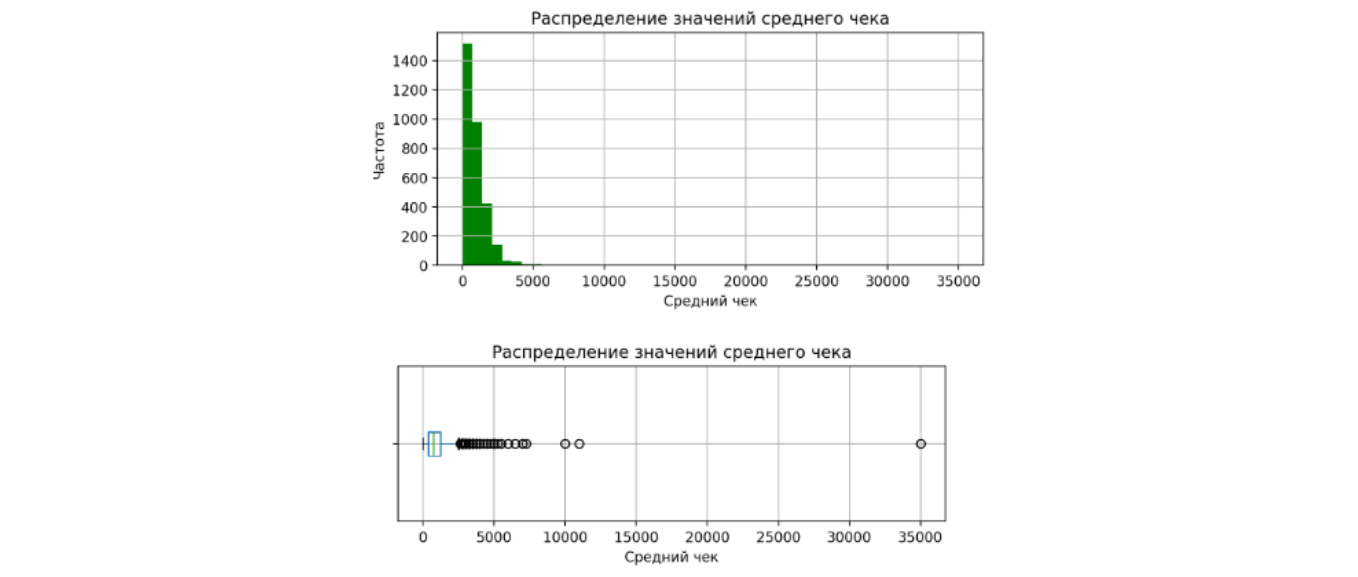

In [70]:
df['district_abbr'] = df['district'].map(district_abbr)

In [71]:
avg_bill_by_district = df.groupby('district_abbr')['middle_avg_bill'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2).sort_values('mean', ascending=False)
avg_bill_by_district

,count,mean,median,std,min,max
district_abbr,,,,,,
ЦАО,1060,1191.06,1000.0,920.01,0.0,7250.0
ЗАО,306,1053.23,1000.0,779.01,50.0,5250.0
САО,322,927.96,650.0,912.61,130.0,11000.0
ЮАО,314,834.40,500.0,2008.64,100.0,35000.0
СЗАО,157,822.22,700.0,595.06,120.0,2900.0
ВАО,260,820.63,575.0,850.90,50.0,10000.0
ЮЗАО,235,792.56,600.0,559.17,100.0,2750.0
СВАО,301,716.61,500.0,591.23,50.0,4500.0
ЮВАО,194,654.10,450.0,566.83,30.0,3750.0


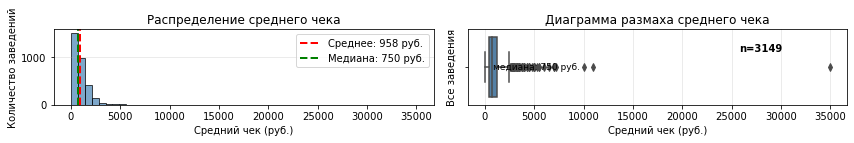

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2))

# 1. Гистограмма
axes[0].hist(df['middle_avg_bill'], bins=50, color='steelblue', 
             edgecolor='black', alpha=0.7)
axes[0].axvline(df['middle_avg_bill'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Среднее: {df["middle_avg_bill"].mean():.0f} руб.')
axes[0].axvline(df['middle_avg_bill'].median(), color='green', 
                linestyle='--', linewidth=2, label=f'Медиана: {df["middle_avg_bill"].median():.0f} руб.')
axes[0].set_xlabel('Средний чек (руб.)')
axes[0].set_ylabel('Количество заведений')
axes[0].set_title('Распределение среднего чека')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Горизонтальный boxplot (удобнее для чтения)
sns.boxplot(data=df, x='middle_avg_bill', ax=axes[1], color='steelblue', orient='h')
axes[1].set_title('Диаграмма размаха среднего чека')
axes[1].set_xlabel('Средний чек (руб.)')
axes[1].set_ylabel('Все заведения')
axes[1].grid(axis='x', alpha=0.3)

# Добавляем статистику
n_total = len(df[df['middle_avg_bill'].notna()])
median_val = df['middle_avg_bill'].median()
mean_val = df['middle_avg_bill'].mean()
axes[1].text(median_val + 50, 0, f'медиана: {median_val:.0f} руб.', va='center', fontsize=9)
axes[1].text(axes[1].get_xlim()[1] * 0.7, -0.2, f'n={n_total}', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Распределение значений среднего чека имеет ярко выраженную правостороннюю асимметрию (скошенность вправо).

- Обоснование: Основная масса значений сконцентрирована в левой части графика (низкие значения среднего чека), а правый «хвост» графика значительно вытянут в сторону высоких значений.

Разброс значений среднего чека крайне широк — от минимальных значений (стремится к нулю) до очень высоких значений (правый край графика).

- Обоснование: Горизонтальная ось «Средний чек» охватывает диапазон от 0 до 35 000 рублей, при этом значения распределены крайне неравномерно.

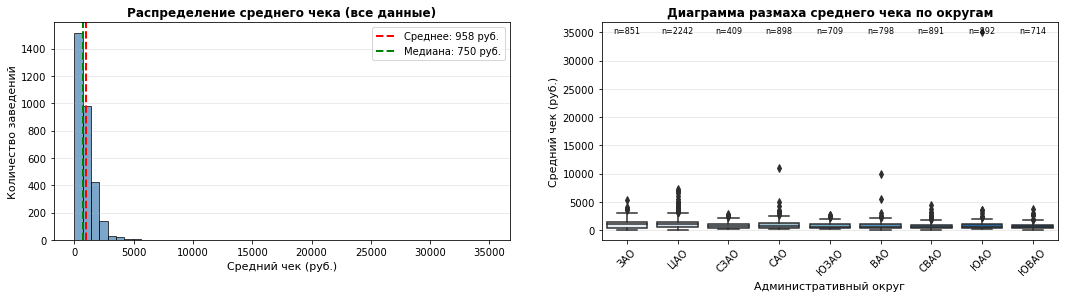

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

axes[0].hist(df['middle_avg_bill'], bins=50, color='steelblue', 
             edgecolor='black', alpha=0.7)
axes[0].axvline(df['middle_avg_bill'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Среднее: {df["middle_avg_bill"].mean():.0f} руб.')
axes[0].axvline(df['middle_avg_bill'].median(), color='green', 
                linestyle='--', linewidth=2, label=f'Медиана: {df["middle_avg_bill"].median():.0f} руб.')
axes[0].set_xlabel('Средний чек (руб.)', fontsize=11)
axes[0].set_ylabel('Количество заведений', fontsize=11)
axes[0].set_title('Распределение среднего чека (все данные)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

order = df.groupby('district_abbr')['middle_avg_bill'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='district_abbr', y='middle_avg_bill', 
            order=order, ax=axes[1], palette='Blues')
axes[1].set_title('Диаграмма размаха среднего чека по округам', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Административный округ', fontsize=11)
axes[1].set_ylabel('Средний чек (руб.)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

for i, district in enumerate(order):
    n = len(df[df['district_abbr'] == district])
    axes[1].text(i, axes[1].get_ylim()[1] * 0.95, f'n={n}', 
                 ha='center', fontsize=8)

Типичный заведение Москвы имеет средний чек 750 руб. (медиана). Высокие выбросы (до 35 000 руб.) искажают среднее до 958 руб. ЦАО ожидаемо дороже других округов. Для оценки «нормального» чека в любом округе следует ориентироваться на медиану, а не на среднее значение.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Сделали анализ центральной тенденции среднего чека заведений по административным округам. Правильно, что представлены и медиана, и среднее, это показывает наличие выбросов среднего чека в отдельных округах.</font>

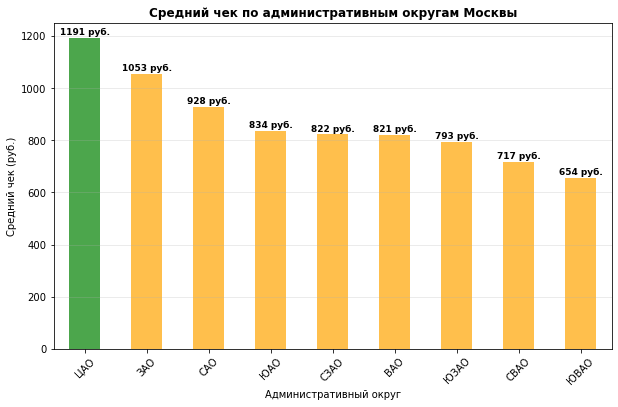

In [74]:
plt.figure(figsize=(10, 6))
ax = avg_bill_by_district['mean'].plot(kind = 'bar', 
               color=['green' if dist == 'ЦАО' else 'orange' for dist in avg_bill_by_district.index],
               alpha=0.7)
plt.xlabel('Административный округ')
plt.ylabel('Средний чек (руб.)')
plt.title('Средний чек по административным округам Москвы', fontweight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_bill_by_district['mean']):
    ax.text(i, v + 5, f'{v:.0f} руб.', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало вывести на диаграмму и медианы, и средние значения, примерно вот так:</font>
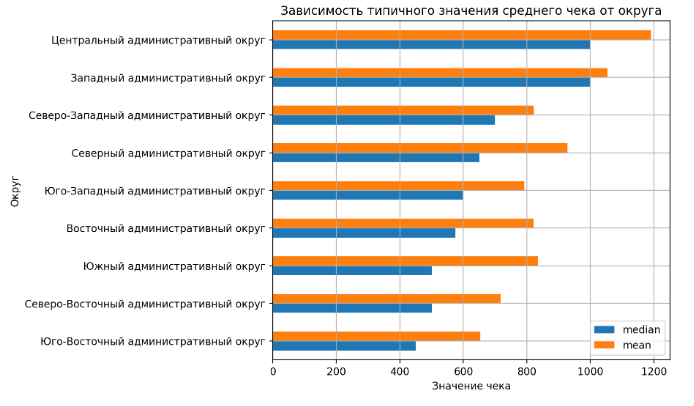

В самом центре города наиболее высокий средний чек (1191), при этом ЗАО не сильно отстает (1053), вероятно потому что часть западного АО находится почти по центру , тем самым происходит небольшое смещение. Со стороны ВАО и ЮВАО находится много больших парковых зон, в которых основную часть территории занимает зелень и растительность. Самый низкий средний чек находится в ЮВАО, возможно, потому что там очень большая концентрация спальных районов и минимальный упор на досуг, развлечения и заведения общественного питания.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Какой бизнес-смысл можно извлечь из этого анализа?</font>

Рынок заведений общепита Москвы поляризован: абсолютное большинство заведений работают в низком и среднем ценовом сегменте, а дорогие заведения с высоким чеком являются редким исключением, а не правилом. Из-за наличия выбросов среднее арифметическое (958 рублей) не отражает реальную ситуацию и завышает представление о типичном чеке. Для корректной оценки рыночных цен следует ориентироваться на медиану (750 рублей), которая показывает, сколько на самом деле платит типичный посетитель.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

СТРУКТУРА РЫНКА
- Доминируют 3 категории: кафе, рестораны, кофейни - вместе 68% рынка
- Высокая концентрация: небольшое количество категорий занимает большую долю рынка
- Длинный хвост: множество нишевых форматов с малым количеством заведений

Ёмкость рынка обратно пропорциональна интенсивности конкуренции. Чем популярнее формат, тем сложнее в нём удержаться без явного преимущества. Нишевые форматы — это игра вдолгую с высокими рисками, но потенциально высокой лояльностью.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вывод необходимо будет переделать после исправления ошибок анализа.</font>  <font color='Blue'>Скорректировал</font>

## 4. Итоговый вывод и рекомендации

####  ОБЩИЙ ОБЗОР ПРОДЕЛАННОЙ РАБОТЫ

Проведено комплексное исследование рынка общественного питания Москвы на основе данных 8 404 заведений. В ходе работы выполнены: предобработка данных с заполнением пропусков и оптимизацией типов, анализ структуры рынка по категориям и районам, исследование сетевого присутствия, изучение вместимости заведений, анализ рейтингов и ценовой политики. Все выводы подтверждены статистическими тестами и визуализациями.

#### ГЛАВНЫЕ ВЫВОДЫ ПО ИССЛЕДОВАТЕЛЬСКИМ ВОПРОСАМ 

1. Вместимость и форматы:
- Типичная вместимость: 80-120 мест для большинства категорий
- Бары и рестораны наиболее вместительные (медиана 111 мест)
- Обнаружены аномалии: от 0 до 1288 мест, связанные с банкетными залами и фаст-фудом навынос
    
2. Качество обслуживания:
- Стабильно высокие рейтинги: 4.1-4.4 по всем категориям
- Лучшие оценки у баров/пабов (4.4) и булочных (4.3)
- Слабые корреляции с анализируемыми факторами

3. Сетевой бизнес:
- Топ-3 сети: Шоколадница (120), Домино'с Пицца (76), Додо Пицца (74)
- Высокие рейтинги у небольших сетей: Буханка (4.40), Кулинарная лавка (4.39)
- Обратная зависимость: крупные сети сложнее поддерживают высокие рейтинги

#### РЕКОМЕНДАЦИИ ДЛЯ ИНВЕСТОРОВ
 Стратегические рекомендации:
1. Выбор локации:
- Оптимально: САО, ЮАО, СВАО - хорошая плотность заведений, умеренная конкуренция
- Избегать: ЦАО (высокая конкуренция и затраты) и СЗАО (низкая плотность)
- Рассмотреть: ЗАО для премиального формата
    
2. Выбор формата:
- Наиболее перспективно: кофейня или специализированное кафе
- Высокий потенциал: булочные/пекарни (высокие рейтинги, умеренные инвестиции)
- Осторожно: рестораны (высокие затраты, сложности с рейтингами)
    
3. Операционные параметры:
- Вместимость: 80-100 мест (оптимальная загрузка)
- Формат: независимое заведение (больше гибкости)
- Фокус: качество обслуживания для поддержания рейтинга выше 4.5

####  ИТОГОВОЕ РЕЗЮМЕ (САМЫЕ ВАЖНЫЕ ВЫВОДЫ)

| № | Вывод | Бизнес-рекомендация |
|---|-------|---------------------|
| 1 | Рынок сверхконцентрирован: кафе, рестораны, кофейни занимают 69% | Входить в эти сегменты — только с сильным УТП |
| 2 | ЦАО — 27% всех заведений, разрыв с другими округами колоссальный | В спальных округах ниже конкуренция, но и ниже чек |
| 3 | Бары и пабы — наименее сетевая категория (78% независимых) | Лучшая ниша для частного заведения |
| 4 | Средний чек в ЦАО на 83% выше, чем в ЮВАО | Ценообразование жёстко привязано к локации |
| 5 | Цена слабо влияет на рейтинг (R² = 0,07) | Качество еды и сервиса важнее ценника |
| 6 | Категория «выше среднего» — самая стабильная по качеству | Оптимальный ценовой сегмент для старта |
| 7 | Медиана чека (750 руб.) — реальный ориентир, не среднее (958 руб.) | Не завышайте ожидания от рынка |
| 8 | Топ-сети по размеру ≠ топ-сети по качеству | Маленькие сети — недооценённый актив |

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошее обобщение всего исследования. 👍</font>
<br><font color='DarkMagenta'>👉 Возможно, что после исправления ошибок его необходимо будет откорректировать.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера</b></font><br><br>
<font color='DarkGreen'>👌 Денис, проект отлично структурирован и проработан.<br>Так держать и дальше!<br></font>
<font color='Red'>🛠 Что нужно, что бы сделать проект лучше:</font><br>
<font color='Red'>🛠 Сделать анализ типов данных датасета, сделать выводы. Вывести количество пропусков в абсолютных значениях. Переделать выводы по первичному анализу и предобработке данных. Сделать анализ количества посадочных мест по всем заведениям. Сделать выводы по анализу типичного количества посадочных мест по категориям заведений. Переделать анализ корреляции рейтинга с другими данными по заведениям, проанализировать самую сильную связь, сделать анализ и визуализацию, сделать выводы. Визуализировать анализ среднего чека заведений гистограммой и диаграммой размаха, сделать выводы анализа. Переделать выводы по разделу исследовательского анализа данных.</font><br>  <font color='Blue'>Скорректировал</font>

<font color='DarkMagenta'>👉 При исправлении ошибок и недочетов будут приобретены дополнительный опыт и навыки!</font><br>
<font color='DarkGreen'>👌 Жду окончательный вариант! Успехов.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Денис!<br></font>
<font color='Red'>🛠 Увы, должен прервать ревью из-за ошибки в коде. Настоятельно рекомендую перед отправкой проекта на ревью проверять в JupyterHub исполнение кода тетрадки (см.скрин ниже).<br>
Жду исправленный проект. Если будут трудности, можно обратиться к наставнику. </font>
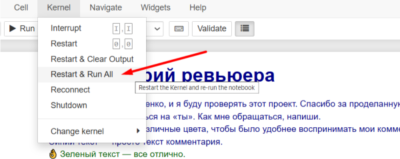